# Theorem 20: Exponential Timescale of Plateauing

This notebook illustrates the central numerical predictions of Theorem 20 using the exact gradient-flow implementation imported from [Experiment 08](../experiments/08_theorem20_exact_gradient_flow.py). It focuses on:

1. an initial loss bounded away from zero,
2. an initial gradient that vanishes as the delay increases,
3. the growth of both hitting times, and
4. the relation to the scale associated with equation (109).

The limit $\omega\to0^+$ is equivalent to $L=1/\omega\to\infty$. Theorem 20 predicts that both hitting times diverge and satisfy an exponential lower bound. The theorem and equation numbering in this notebook follow the 2022 JMLR paper by [Li, Han, E, and Li, *Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks*](https://jmlr.org/papers/v23/21-0368.html), specifically Theorem 20 and equations (107)-(109) on pages 27-28.

## 1. Mathematical setup

The numerical experiment instantiates the delayed-target family in equation (102) of [Li et al. (2022)](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf#page=26). The target consists of a short-memory component and a spike delayed by $L=1/\omega$:

$$
\rho_\omega(t)=\bar\rho(t)+\rho_0\!\left(t-\frac{1}{\omega}\right).
$$

The linear continuous-time RNN generates the kernel

$$
\widehat\rho(t;\theta)=\sum_{i=1}^{m}a_i e^{-w_i t},
$$

and minimizes the exact loss on the unbounded time interval

$$
J_\omega(\theta)=\int_0^\infty\left|\widehat\rho(t;\theta)-\rho_\omega(t)\right|^2\,dt.
$$

The initialization satisfies $\widehat\rho(t;\theta_0)=\bar\rho(t)$. For the two thresholds, define the first hitting times

$$
\tau_0=\inf\{\tau:\|\theta(\tau)-\theta_0\|_2>\delta_\theta\},
\qquad
\tau_0'=\inf\{\tau:J_\omega(\theta_0)-J_\omega(\theta(\tau))>\delta_J\}
$$

The JMLR paper defines these quantities in equations (105)-(106) of [Theorem 20](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf#page=27), writing the loss condition as $|J_\omega(\theta(\tau))-J_\omega(\theta_0)|>\delta_J$. Along exact gradient flow, $J_\omega$ is nonincreasing, so this is equivalent to the monotone loss decrease used above; the implementation additionally checks numerical loss monotonicity. The definitions alone do not imply a fixed ordering between $\tau_0$ and $\tau_0'$; the ordering in equation (109) is a theorem conclusion under its stated assumptions.

## 2. Imports and configuration

The loss, gradient, exact half-line integrals, event functions, and solver configurations are imported directly from [Experiment 08](../experiments/08_theorem20_exact_gradient_flow.py); this notebook defines only presentation and cache helpers. Experiment 08 uses SciPy's [`solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) for adaptive initial-value integration and event detection, [`quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) for independent quadrature validation, and [`erfc`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.erfc.html) together with [`erfcx`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.erfcx.html) for stable Gaussian Laplace-moment evaluation.

In [1]:
from pathlib import Path
import contextlib
import hashlib
import importlib.util
import io
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
EXPERIMENT_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "08_theorem20_exact_gradient_flow.py"
)

if not EXPERIMENT_PATH.exists():
    raise FileNotFoundError(
        f"Experiment implementation not found: {EXPERIMENT_PATH}"
    )

module_name = "theorem20_exact_gradient_flow"
spec = importlib.util.spec_from_file_location(
    module_name,
    EXPERIMENT_PATH,
)

if spec is None or spec.loader is None:
    raise ImportError(f"Cannot import {EXPERIMENT_PATH}")

exp = importlib.util.module_from_spec(spec)
sys.modules[module_name] = exp
spec.loader.exec_module(exp)

PLOT_STYLE = {
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
}

CACHE_DIR = PROJECT_ROOT / "notebooks" / ".cache"
CACHE_PATH = CACHE_DIR / "08_theorem20_plateauing_results.pkl"
CACHE_SCHEMA_VERSION = 1

print(f"Experiment module: {EXPERIMENT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Cache file: {CACHE_PATH.relative_to(PROJECT_ROOT)}")

Experiment module: experiments/08_theorem20_exact_gradient_flow.py
Cache file: notebooks/.cache/08_theorem20_plateauing_results.pkl


## 3. The delayed target kernel

For the three delays $L\in\{8,12,18\}$, the spike retains its shape and amplitude while its position moves to the right. This directly visualizes the translation $\rho_0(t-1/\omega)$ in equation (102) of [Li et al. (2022)](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf#page=26).

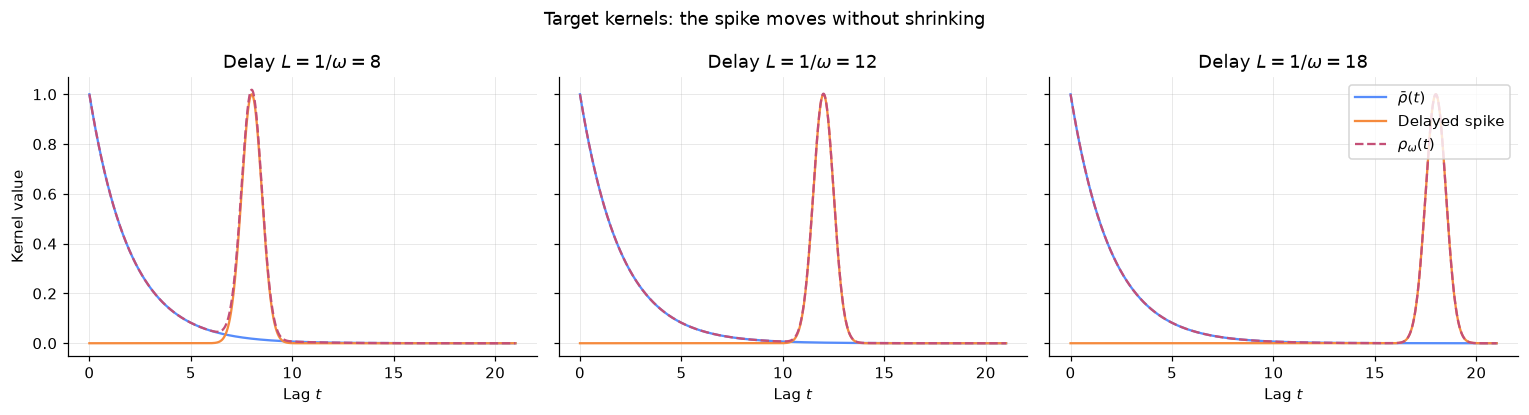

In [2]:
target_delays = [8.0, 12.0, 18.0]
target_times = np.linspace(0.0, 21.0, 2400)

with plt.rc_context(PLOT_STYLE):
    figure, axes = plt.subplots(
        1,
        len(target_delays),
        figsize=(14, 3.8),
        sharey=True,
    )

    for axis, delay in zip(axes, target_delays, strict=True):
        baseline = exp.short_memory_target(target_times)
        spike = exp.delayed_memory_spike(target_times, delay)
        target = exp.target_kernel(target_times, delay)

        axis.plot(target_times, baseline, label=r"$\bar\rho(t)$")
        axis.plot(target_times, spike, label="Delayed spike")
        axis.plot(
            target_times,
            target,
            linestyle="--",
            label=r"$\rho_\omega(t)$",
        )
        axis.set_title(rf"Delay $L=1/\omega={delay:.0f}$")
        axis.set_xlabel(r"Lag $t$")

    axes[0].set_ylabel("Kernel value")
    axes[-1].legend(loc="upper right")
    figure.suptitle("Target kernels: the spike moves without shrinking")
    figure.tight_layout()
    plt.show()

### Interpretation

Increasing the delay $L=1/\omega$ shifts the long-memory spike further to the right while leaving its shape, width, and amplitude unchanged. The short-memory component $\bar{\rho}(t)$ remains fixed.

Consequently, the magnitude of the additional target component does not decrease as the memory becomes longer. Its squared $L^2$-norm satisfies

$$
\int_0^\infty
\left|\rho_0\left(t-\frac{1}{\omega}\right)\right|^2\,dt
=
\int_{-1/\omega}^{\infty}
|\rho_0(s)|^2\,ds
\longrightarrow
\|\rho_0\|_{L^2(\mathbb{R})}^2
\qquad (\omega\to0^+).
$$

Thus, the learning problem does not become difficult because the delayed signal becomes weaker. Instead, it becomes difficult because the signal is located at increasingly large time lags, where the exponentially decaying model components have very little overlap with it.

## 4. Initialization and residual

For $L=14$, the initial model exactly matches the short-memory component of the target. Consequently, the initial residual is

$$
r_\omega(t;\theta_0)=\widehat\rho(t;\theta_0)-\rho_\omega(t)=-\rho_0(t-L).
$$

## 5. Baseline results: compute once, then load from cache

The following cell runs the numerical experiment and caches the resulting arrays. If the experiment code changes, the cache is automatically recomputed.

In [6]:
RESULT_FIELDS = (
    "memory_length",
    "omega",
    "initial_loss",
    "initial_gradient_norm",
    "parameter_hitting_time",
    "loss_hitting_time",
    "rate_abort_time",
    "stopping_time",
    "training_times",
    "loss_history",
    "loss_change_history",
    "gradient_norm_history",
    "parameter_distance_history",
    "minimum_rate_history",
    "final_coefficients",
    "final_rates",
)


def result_to_record(result):
    record = {}
    for field in RESULT_FIELDS:
        value = getattr(result, field)
        record[field] = value.copy() if isinstance(value, np.ndarray) else value
    return record


source_digest = hashlib.sha256(EXPERIMENT_PATH.read_bytes()).hexdigest()
cache_payload = None

if CACHE_PATH.exists():
    try:
        with CACHE_PATH.open("rb") as cache_file:
            candidate = pickle.load(cache_file)
        if (
            candidate.get("schema_version") == CACHE_SCHEMA_VERSION
            and candidate.get("source_digest") == source_digest
        ):
            cache_payload = candidate
    except (OSError, EOFError, pickle.PickleError, TypeError, ValueError):
        cache_payload = None

if cache_payload is None:
    solver_log = io.StringIO()
    with contextlib.redirect_stdout(solver_log):
        primary_raw = exp.run_experiment(exp.PRIMARY_SOLVER)
        refined_raw = exp.run_experiment(exp.REFINED_SOLVER)
        parameter_differences, loss_differences = (
            exp.compare_solver_configurations(primary_raw, refined_raw)
        )
        illustrative_raw = exp.run_illustrative_trajectories(
            primary_raw,
            exp.PRIMARY_SOLVER,
        )

    validation = {
        "initialization_error": exp.initialization_check(),
        "gradient_relative_error": exp.finite_difference_gradient_check(),
        "quadrature_relative_error": exp.quadrature_loss_check(),
        "maximum_solver_relative_difference": float(
            np.nanmax(
                np.concatenate(
                    [parameter_differences, loss_differences]
                )
            )
        ),
    }

    cache_payload = {
        "schema_version": CACHE_SCHEMA_VERSION,
        "source_digest": source_digest,
        "primary": [result_to_record(item) for item in primary_raw],
        "refined": [result_to_record(item) for item in refined_raw],
        "illustrative": [
            result_to_record(item) for item in illustrative_raw
        ],
        "parameter_differences": parameter_differences.copy(),
        "loss_differences": loss_differences.copy(),
        "validation": validation,
    }

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    temporary_cache_path = CACHE_PATH.with_suffix(".tmp")
    with temporary_cache_path.open("wb") as cache_file:
        pickle.dump(cache_payload, cache_file, protocol=pickle.HIGHEST_PROTOCOL)
    temporary_cache_path.replace(CACHE_PATH)
    cache_status = "computed once and cached"
else:
    cache_status = "loaded from cache; no solver was called"

primary_results = cache_payload["primary"]
refined_results = cache_payload["refined"]
illustrative_results = cache_payload["illustrative"]
validation_results = cache_payload["validation"]
parameter_differences = cache_payload["parameter_differences"]
loss_differences = cache_payload["loss_differences"]

print(f"Cache status: {cache_status}")
print(
    f"Loaded {len(primary_results)} primary, "
    f"{len(refined_results)} refined, and "
    f"{len(illustrative_results)} illustrative trajectories."
)

Cache status: loaded from cache; no solver was called
Loaded 6 primary, 6 refined, and 3 illustrative trajectories.


In [7]:

baseline_table = pd.DataFrame(
    {
        r"$1/\omega$": [item["memory_length"] for item in primary_results],
        r"$\omega$": [item["omega"] for item in primary_results],
        r"$J_\omega(\theta_0)$": [
            item["initial_loss"] for item in primary_results
        ],
        r"$\|\nabla J_\omega(\theta_0)\|_2$": [
            item["initial_gradient_norm"] for item in primary_results
        ],
        r"$\tau_0$": [
            item["parameter_hitting_time"] for item in primary_results
        ],
        r"$\tau_0'$": [
            item["loss_hitting_time"] for item in primary_results
        ],
    }
)

display(
    baseline_table.style.format(precision=6).hide(axis="index")
)

$1/\omega$,$\omega$,$J_\omega(\theta_0)$,$\|\nabla J_\omega(\theta_0)\|_2$,$\tau_0$,$\tau_0'$
8.000000,0.125000,0.886227,0.376435,0.145128,0.560220
10.000000,0.100000,0.886227,0.173029,0.409061,4.485600
12.000000,0.083333,0.886227,0.076407,1.632855,17.430032
14.000000,0.071429,0.886227,0.032809,5.954056,63.396123
16.000000,0.062500,0.886227,0.013800,22.779046,233.191643
18.000000,0.055556,0.886227,0.005714,72.326708,881.764264


**Table entries.**
Here, $1/\omega$ is the delay of the long-memory spike and $\omega$ is the corresponding memory parameter. The quantity $J_\omega(\theta_0)$ is the initial loss, while $\|\nabla J_\omega(\theta_0)\|_2$ denotes the norm of the initial gradient. Furthermore, $\tau_0$ is the first time at which the parameter distance exceeds the threshold $\delta$, and $\tau_0'$ is the first time at which the loss decrease exceeds the same threshold.

## 6. Initial loss and initial gradient

The initialization leaves only the delayed spike as a residual. Therefore, $J_\omega(\theta_0)$ remains approximately on the scale $\|\rho_0\|_{L^2}^2$, while the overlap between the exponential model and the distant spike decreases rapidly. This is the large-loss/small-gradient configuration underlying [Theorem 20 in Li et al. (2022)](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf#page=27).

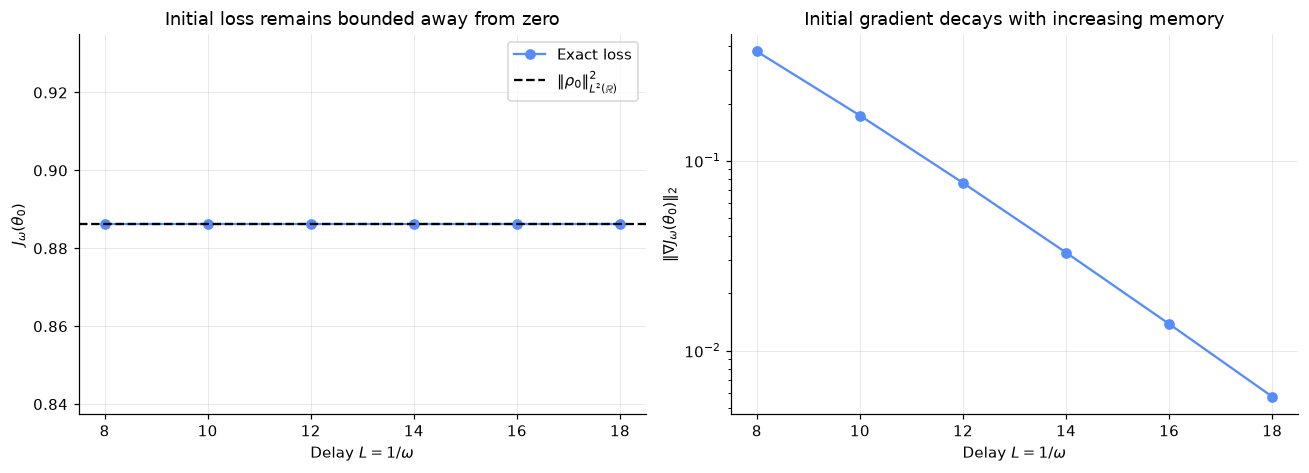

In [10]:
delays = np.array([item["memory_length"] for item in primary_results])
initial_losses = np.array([item["initial_loss"] for item in primary_results])
initial_gradients = np.array(
    [item["initial_gradient_norm"] for item in primary_results]
)
spike_squared_norm = (
    exp.SPIKE_AMPLITUDE**2 * exp.SPIKE_WIDTH * np.sqrt(np.pi)
)

with plt.rc_context(PLOT_STYLE):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.4))

    axes[0].plot(delays, initial_losses, marker="o", label="Exact loss")
    axes[0].axhline(
        spike_squared_norm,
        color="black",
        linestyle="--",
        label=r"$\|\rho_0\|_{L^2(\mathbb{R})}^2$",
    )
    axes[0].set_xlabel(r"Delay $L=1/\omega$")
    axes[0].set_ylabel(r"$J_\omega(\theta_0)$")
    axes[0].set_title("Initial loss remains bounded away from zero")
    axes[0].legend()

    axes[1].semilogy(delays, initial_gradients, marker="o")
    axes[1].set_xlabel(r"Delay $L=1/\omega$")
    axes[1].set_ylabel(r"$\|\nabla J_\omega(\theta_0)\|_2$")
    axes[1].set_title("Initial gradient decays with increasing memory")

    figure.tight_layout()
    plt.show()

### Interpretation

The initial loss is essentially independent of the delay $1/\omega$. Since the initial model satisfies

$$
\widehat{\rho}(t;\theta_0)=\bar{\rho}(t),
$$

the initial residual is exactly the delayed spike. Therefore,

$$
J_\omega(\theta_0)
=
\int_0^\infty
\left|
\rho_0\left(t-\frac{1}{\omega}\right)
\right|^2\,dt
\approx
\|\rho_0\|_{L^2(\mathbb{R})}^2,
$$

which remains bounded away from zero as $\omega\to0^+$.

In contrast, the initial gradient becomes small because the derivatives of the model are exponentially localized near small time lags. At initialization,

$$
\widehat{\rho}(t;\theta_0)=\bar{\rho}(t),
$$

and therefore the residual is

$$
\widehat{\rho}(t;\theta_0)-\rho_\omega(t)
=
-\rho_0\left(t-\frac{1}{\omega}\right).
$$

For the coefficient $a_k$, the gradient is

$$
\frac{\partial J_\omega}{\partial a_k}(\theta_0)
=
2\int_0^\infty
e^{-w_k^0t}
\left[
\widehat{\rho}(t;\theta_0)-\rho_\omega(t)
\right]dt.
$$

Using the initial residual and the substitution

$$
s=t-\frac{1}{\omega},
$$

we obtain

$$
\frac{\partial J_\omega}{\partial a_k}(\theta_0)
=
-2e^{-w_k^0/\omega}
\int_{-1/\omega}^{\infty}
e^{-w_k^0s}\rho_0(s)\,ds.
$$

Since $\rho_0$ is localized and has rapidly decaying tails, the remaining integral stays bounded as $\omega\to0^+$. Hence,

$$
\frac{\partial J_\omega}{\partial a_k}(\theta_0)
=
O\left(e^{-w_k^0/\omega}\right).
$$

For the decay rate $w_k$, we use

$$
\frac{\partial\widehat{\rho}}{\partial w_k}
=
-a_k t e^{-w_kt}.
$$

Therefore,

$$
\frac{\partial J_\omega}{\partial w_k}(\theta_0)
=
2a_k^0
\int_0^\infty
t e^{-w_k^0t}
\rho_0\left(t-\frac{1}{\omega}\right)dt.
$$

After the same substitution,

$$
\frac{\partial J_\omega}{\partial w_k}(\theta_0)
=
2a_k^0e^{-w_k^0/\omega}
\int_{-1/\omega}^{\infty}
\left(s+\frac{1}{\omega}\right)
e^{-w_k^0s}\rho_0(s)\,ds.
$$

Consequently,

$$
\frac{\partial J_\omega}{\partial w_k}(\theta_0)
=
O\left(
\frac{1}{\omega}e^{-w_k^0/\omega}
\right).
$$

The components with $a_k^0=0$ have zero rate gradient at initialization. Overall, the slowest initial decay rate

$$
w_{\min}^0=\min_k w_k^0
$$

determines the dominant exponential scale, giving

$$
\|\nabla J_\omega(\theta_0)\|_2
=
O\left(
\frac{1}{\omega}
e^{-w_{\min}^0/\omega}
\right)
\longrightarrow 0
\qquad
(\omega\to0^+).
$$

At the same time,

$$
J_\omega(\theta_0)
=
\int_0^\infty
\left|
\rho_0\left(t-\frac{1}{\omega}\right)
\right|^2dt
\longrightarrow
\|\rho_0\|_{L^2(\mathbb{R})}^2
>0.
$$

Thus, increasing the memory produces a non-vanishing initial loss but an exponentially small initial gradient. This is the local mechanism behind the increasingly long optimization plateau.

## 7. Hitting Times

On a logarithmic $y$-axis, an approximately linear dependence on $L=1/\omega$ corresponds to exponential growth. This is the diagnostic used in Figure 3 of [Li et al. (2022), Section 6.2.2](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf#page=31). Following the experiment configuration, the fits use the points with $L\geq10$.

Hitting time,Slope $\alpha$,Intercept $\beta$,$R^2$
$\tau_0$,0.649284,-7.332467,0.999117
$\tau_0'$,0.657789,-5.060588,0.999938


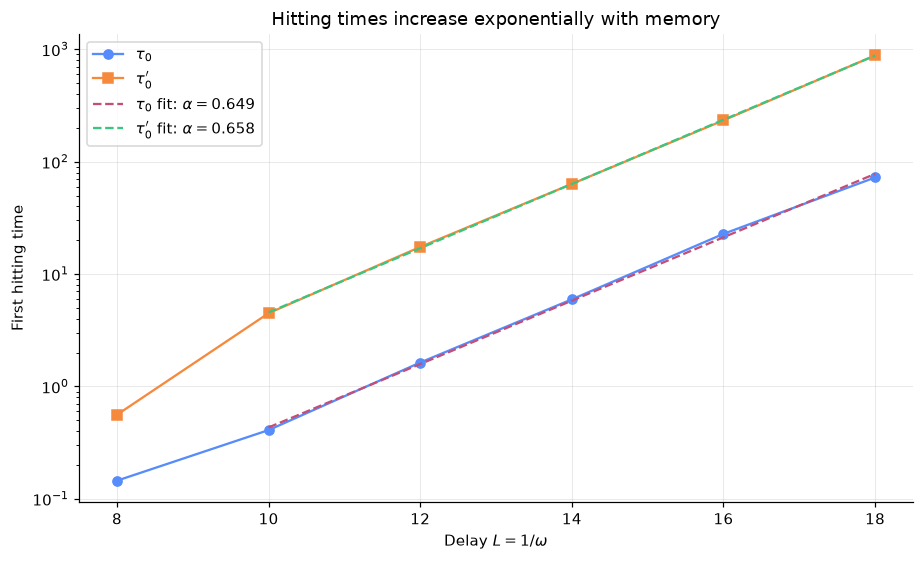

In [11]:
parameter_times = np.array(
    [item["parameter_hitting_time"] for item in primary_results]
)
loss_times = np.array([item["loss_hitting_time"] for item in primary_results])
fit_mask = delays >= exp.FIT_MINIMUM_MEMORY_LENGTH


def semilog_fit(x_values, y_values):
    slope, intercept = np.polyfit(x_values, np.log(y_values), deg=1)
    fitted_log_values = slope * x_values + intercept
    observed_log_values = np.log(y_values)
    residual_sum = np.sum((observed_log_values - fitted_log_values) ** 2)
    total_sum = np.sum(
        (observed_log_values - np.mean(observed_log_values)) ** 2
    )
    r_squared = 1.0 - residual_sum / total_sum
    return slope, intercept, r_squared


parameter_fit = semilog_fit(delays[fit_mask], parameter_times[fit_mask])
loss_fit = semilog_fit(delays[fit_mask], loss_times[fit_mask])

fit_table = pd.DataFrame(
    {
        "Hitting time": [r"$\tau_0$", r"$\tau_0'$"],
        r"Slope $\alpha$": [parameter_fit[0], loss_fit[0]],
        r"Intercept $\beta$": [parameter_fit[1], loss_fit[1]],
        r"$R^2$": [parameter_fit[2], loss_fit[2]],
    }
)
display(fit_table.style.format(precision=6).hide(axis="index"))

fit_delays = np.linspace(delays[fit_mask].min(), delays[fit_mask].max(), 240)

with plt.rc_context(PLOT_STYLE):
    figure, axis = plt.subplots(figsize=(8.5, 5.2))
    axis.semilogy(delays, parameter_times, marker="o", label=r"$\tau_0$")
    axis.semilogy(delays, loss_times, marker="s", label=r"$\tau_0'$")
    axis.semilogy(
        fit_delays,
        np.exp(parameter_fit[0] * fit_delays + parameter_fit[1]),
        linestyle="--",
        label=rf"$\tau_0$ fit: $\alpha={parameter_fit[0]:.3f}$",
    )
    axis.semilogy(
        fit_delays,
        np.exp(loss_fit[0] * fit_delays + loss_fit[1]),
        linestyle="--",
        label=rf"$\tau_0'$ fit: $\alpha={loss_fit[0]:.3f}$",
    )
    axis.set_xlabel(r"Delay $L=1/\omega$")
    axis.set_ylabel("First hitting time")
    axis.set_title("Hitting times increase exponentially with memory")
    axis.legend()
    figure.tight_layout()
    plt.show()

### Hitting times

The parameter hitting time is defined by

$$
\tau_0(\delta_\theta;\omega,m,\theta_0)
=
\inf
\left\{
\tau\geq 0:
\left\|
\theta_\omega(\tau)-\theta_0
\right\|_2
>
\delta_\theta
\right\}.
$$

It measures how long the gradient-flow trajectory remains within a ball of radius $\delta_\theta$ around the initialization.

The loss hitting time is defined by

$$
\tau_0'(\delta_J;\omega,m,\theta_0)
=
\inf
\left\{
\tau\geq 0:
J_\omega(\theta_0)
-
J_\omega\bigl(\theta_\omega(\tau)\bigr)
>
\delta_J
\right\}.
$$

It measures how long it takes until the loss has decreased by more than $\delta_J$. In the present experiment,

$$
\delta_\theta=\delta_J=0.05.
$$

### Interpretation

Both hitting times increase rapidly as the delay

$$
L=\frac{1}{\omega}
$$

becomes larger. Since the vertical axis is logarithmic, an approximately straight line indicates an exponential dependence on $L$.

The fitted relations have the form

$$
\log \tau_0
=
\alpha_\theta L+\beta_\theta,
$$

and

$$
\log \tau_0'
=
\alpha_J L+\beta_J.
$$

Equivalently,

$$
\tau_0
\approx
e^{\beta_\theta}e^{\alpha_\theta L}
=
e^{\beta_\theta}
e^{\alpha_\theta/\omega},
$$

and

$$
\tau_0'
\approx
e^{\beta_J}e^{\alpha_J L}
=
e^{\beta_J}
e^{\alpha_J/\omega}.
$$

The fitted slopes are

$$
\alpha_\theta\approx 0.649,
\qquad
\alpha_J\approx 0.658,
$$

with

$$
R_\theta^2\approx0.9999,
\qquad
R_J^2\approx0.9999.
$$

Hence, over the investigated range, both hitting times are extremely well described by exponential growth in $1/\omega$. The similar slopes indicate that parameter escape and noticeable loss reduction occur on comparable exponential scales, although the loss hitting time is consistently larger.

Numerically,

$$
\tau_0:
0.145
\longrightarrow
72.327,
$$

whereas

$$
\tau_0':
0.560
\longrightarrow
881.764
$$

as $L$ increases from $8$ to $18$. The experiment therefore strongly supports the prediction

$$
\tau_0(\delta;\omega,m,\theta_0)
\longrightarrow\infty,
\qquad
\tau_0'(\delta;\omega,m,\theta_0)
\longrightarrow\infty
$$

as $\omega\to0^+$.

This is numerical evidence rather than a proof of the limit, since only finitely many values of $\omega$ are tested.

## 8. Individual gradient-flow trajectories

The separate illustrative runs for $L\in\{10,14,18\}$ integrate beyond the loss hitting time without a terminal joint-threshold event. A symmetric logarithmic time axis preserves the initial point $\tau=0$ and behaves logarithmically outside a small linear neighborhood.

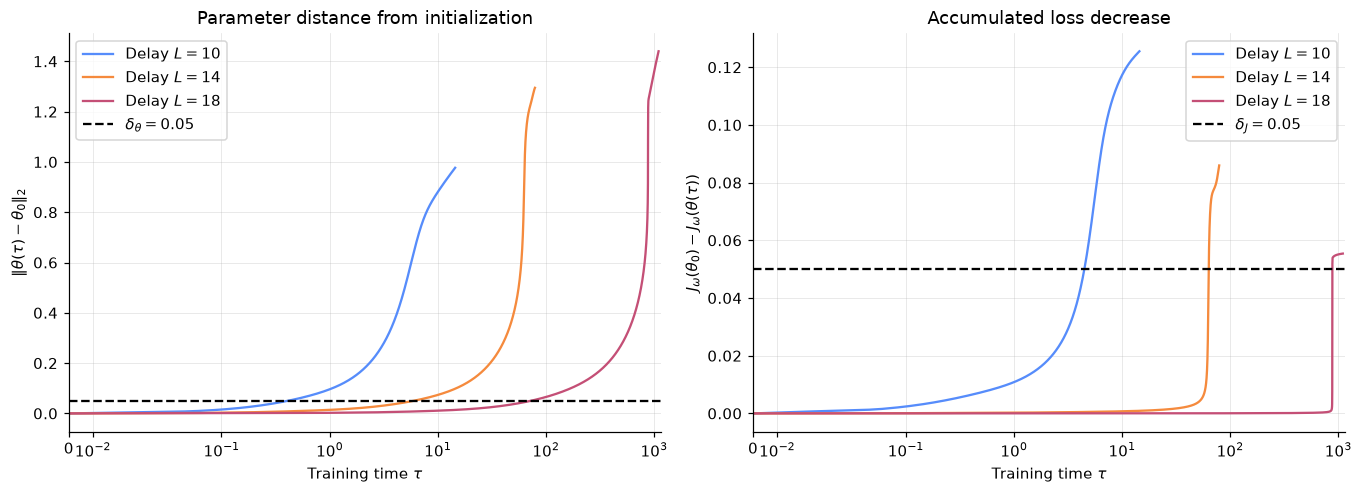

In [12]:
with plt.rc_context(PLOT_STYLE):
    figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

    for item in illustrative_results:
        label = rf"Delay $L={item['memory_length']:.0f}$"
        axes[0].plot(
            item["training_times"],
            item["parameter_distance_history"],
            label=label,
        )
        axes[1].plot(
            item["training_times"],
            item["loss_change_history"],
            label=label,
        )

    axes[0].axhline(
        exp.PARAMETER_THRESHOLD,
        color="black",
        linestyle="--",
        label=rf"$\delta_\theta={exp.PARAMETER_THRESHOLD}$",
    )
    axes[1].axhline(
        exp.LOSS_THRESHOLD,
        color="black",
        linestyle="--",
        label=rf"$\delta_J={exp.LOSS_THRESHOLD}$",
    )

    for axis in axes:
        axis.set_xscale("symlog", linthresh=0.05)
        axis.set_xlim(left=0.0)
        axis.set_xlabel(r"Training time $\tau$")
        axis.legend()

    axes[0].set_ylabel(r"$\|\theta(\tau)-\theta_0\|_2$")
    axes[0].set_title("Parameter distance from initialization")
    axes[1].set_ylabel(
        r"$J_\omega(\theta_0)-J_\omega(\theta(\tau))$"
    )
    axes[1].set_title("Accumulated loss decrease")

    figure.tight_layout()
    plt.show()

> **Interpretation**
>

### Why is the loss decrease monotone?

For the exact gradient flow $\dot\theta=-\nabla J_\omega(\theta)$, corresponding to equation (104) in [Li et al. (2022)](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf#page=27),

$$
\frac{d}{d\tau}J_\omega(\theta(\tau))=-\|\nabla J_\omega(\theta(\tau))\|_2^2\leq0,
$$

and therefore

$$
\frac{d}{d\tau}\left[J_\omega(\theta_0)-J_\omega(\theta(\tau))\right]=\|\nabla J_\omega(\theta(\tau))\|_2^2\geq0.
$$

The mechanism behind the initial plateau can be summarized as

$$
\omega\downarrow\ \Longrightarrow\ L=1/\omega\uparrow\ \Longrightarrow\ \text{smaller overlap with the spike}\ \Longrightarrow\ \text{smaller gradient}\ \Longrightarrow\ \text{longer plateau}.
$$

## 9. Scaling diagnostic for equation (109)

Under the sub-Gaussian tail assumption on $\rho_0$ and the bounded-initialization assumptions of Theorem 20, equation (109) states

$$
\tau_0'(\delta;\omega,m,\theta_0)
\geq
\tau_0(\delta;\omega,m,\theta_0)
\gtrsim
\omega^2
e^{w_l^0/\omega}
\min
\left\{
\frac{\delta}{\sqrt{m}},
\ln(1+\delta)
\right\}.
$$

Here, $w_l^0>0$ is the lower bound on the initial decay rates,

$$
w_{0,i}\geq w_l^0,
\qquad i=1,\ldots,m,
$$

and $\gtrsim$ hides a positive multiplicative constant independent of $\omega$, $m$, and $\delta$.

For the numerical diagnostic, define

$$
S(\omega)
=
\omega^2
e^{w_l^0/\omega}
\min
\left\{
\frac{\delta}{\sqrt{m}},
\ln(1+\delta)
\right\}.
$$

Equation (109) can therefore be written as

$$
\tau_0'(\delta;\omega,m,\theta_0)
\geq
\tau_0(\delta;\omega,m,\theta_0)
\gtrsim
S(\omega).
$$

The ratios $\tau_0/S(\omega)$ and $\tau_0'/S(\omega)$ provide only a consistency check. Since the multiplicative constant hidden in $\gtrsim$ is unknown, the experiment neither proves the lower bound nor establishes an asymptotic equality.

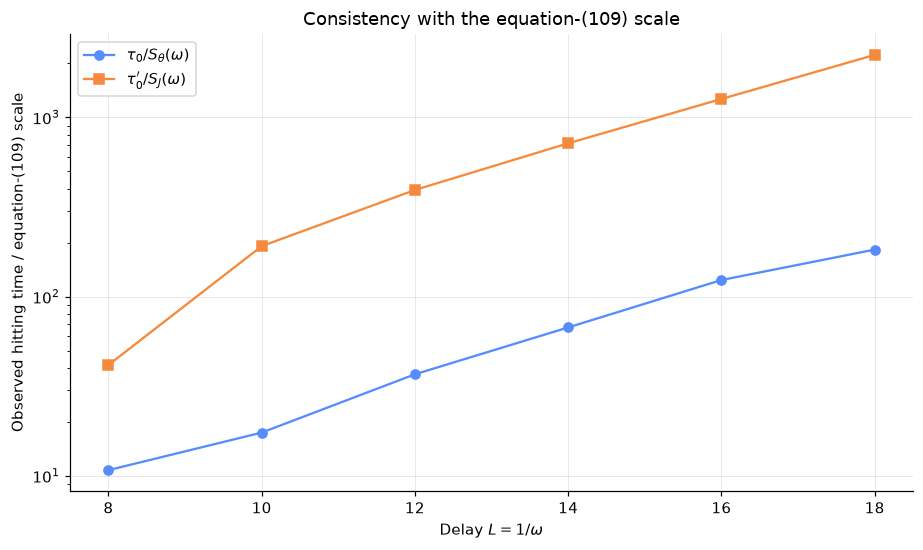

In [13]:
parameter_scales = np.array(
    [
        exp.theorem_20_scale(item["omega"], exp.PARAMETER_THRESHOLD)
        for item in primary_results
    ]
)
loss_scales = np.array(
    [
        exp.theorem_20_scale(item["omega"], exp.LOSS_THRESHOLD)
        for item in primary_results
    ]
)

with plt.rc_context(PLOT_STYLE):
    figure, axis = plt.subplots(figsize=(8.5, 5.1))
    axis.semilogy(
        delays,
        parameter_times / parameter_scales,
        marker="o",
        label=r"$\tau_0/S_\theta(\omega)$",
    )
    axis.semilogy(
        delays,
        loss_times / loss_scales,
        marker="s",
        label=r"$\tau_0'/S_J(\omega)$",
    )
    axis.set_xlabel(r"Delay $L=1/\omega$")
    axis.set_ylabel("Observed hitting time / equation-(109) scale")
    axis.set_title("Consistency with the equation-(109) scale")
    axis.legend()
    figure.tight_layout()
    plt.show()

### Interpretation

Equation (109) predicts the lower-bound scale

$$
S(\omega)
=
\omega^2
e^{w_l^0/\omega}
\min
\left\{
\frac{\delta}{\sqrt{m}},
\ln(1+\delta)
\right\}
$$

for both hitting times. Hence, if the bound is consistent with the numerical results, the ratios

$$
\frac{\tau_0}{S(\omega)}
\qquad\text{and}\qquad
\frac{\tau_0'}{S(\omega)}
$$

should not tend to zero as $\omega\to0^+$.

In the experiment, both ratios remain positive and increase as the delay $1/\omega$ grows. Thus, the observed hitting times grow at least as rapidly as the scale appearing in equation (109) over the tested range. In particular, there is no numerical indication that either hitting time grows more slowly than the predicted lower-bound scale.

The increasing ratios also show that equation (109) is not an asymptotic equality for this experiment. The observed hitting times grow faster than the displayed scale:

$$
\tau_0
\neq
C\,S(\omega)
$$

with an approximately constant ratio over the tested values. This is fully compatible with the theorem, since

$$
\tau_0\gtrsim S(\omega)
$$

is only a lower bound.

The larger values of

$$
\frac{\tau_0'}{S(\omega)}
$$

reflect that a noticeable loss decrease occurs later than the corresponding parameter displacement in this experiment. Indeed,

$$
\tau_0' \geq \tau_0
$$

holds for every tested value of $\omega$.

Because the multiplicative constant hidden in $\gtrsim$ is unknown and only finitely many memory parameters are considered, the plot provides a consistency check rather than a numerical proof of equation (109).

## 10. Slowest learned rate

The slowest final rate defines the largest learned model timescale $1/w_{\min,\mathrm{final}}$. Only these summary quantities are shown, rather than all ten learned parameters.

$\omega$,"$w_{\min,\mathrm{final}}$","$1/w_{\min,\mathrm{final}}$",$1/\omega$
0.100000,0.110762,9.028382,10.000000
0.071429,0.075964,13.164192,14.000000
0.055556,0.044799,22.321957,18.000000


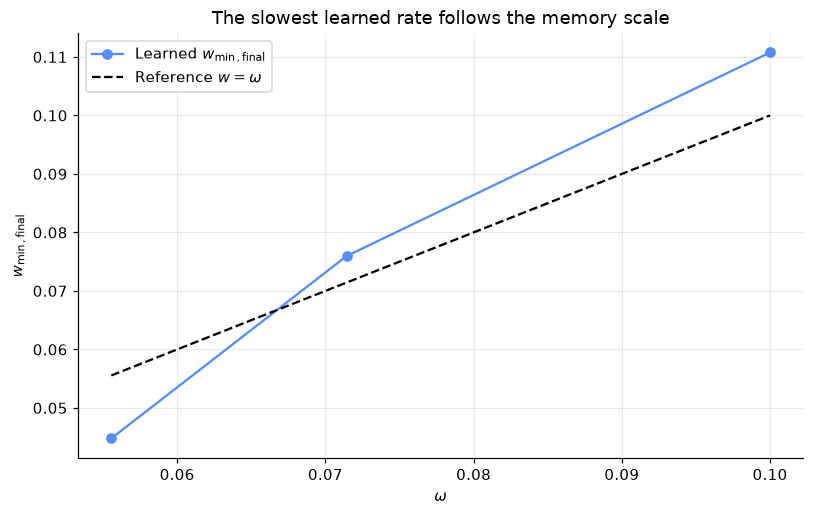

In [14]:
slow_rate_table = pd.DataFrame(
    {
        r"$\omega$": [item["omega"] for item in illustrative_results],
        r"$w_{\min,\mathrm{final}}$": [
            np.min(item["final_rates"]) for item in illustrative_results
        ],
        r"$1/w_{\min,\mathrm{final}}$": [
            1.0 / np.min(item["final_rates"]) for item in illustrative_results
        ],
        r"$1/\omega$": [
            item["memory_length"] for item in illustrative_results
        ],
    }
)
display(slow_rate_table.style.format(precision=6).hide(axis="index"))

sorted_rates = slow_rate_table.sort_values(r"$\omega$")

with plt.rc_context(PLOT_STYLE):
    figure, axis = plt.subplots(figsize=(7.5, 4.8))
    axis.plot(
        sorted_rates[r"$\omega$"],
        sorted_rates[r"$w_{\min,\mathrm{final}}$"],
        marker="o",
        label=r"Learned $w_{\min,\mathrm{final}}$",
    )
    axis.plot(
        sorted_rates[r"$\omega$"],
        sorted_rates[r"$\omega$"],
        linestyle="--",
        color="black",
        label=r"Reference $w=\omega$",
    )
    axis.set_xlabel(r"$\omega$")
    axis.set_ylabel(r"$w_{\min,\mathrm{final}}$")
    axis.set_title("The slowest learned rate follows the memory scale")
    axis.legend()
    figure.tight_layout()
    plt.show()

### Interpretation

An exponential component of the form

$$
a_i e^{-w_i t}
$$

has the characteristic time scale

$$
\frac{1}{w_i}.
$$

The delayed spike is located at

$$
t=\frac{1}{\omega}.
$$

At this position, the contribution of one exponential component is

$$
e^{-w_i/\omega}.
$$

If $w_i$ were much larger than $\omega$, then

$$
\frac{w_i}{\omega}\gg 1
$$

and therefore

$$
e^{-w_i/\omega}\approx 0.
$$

Such a component would have essentially vanished before reaching the delayed spike. To retain a non-negligible value near $t=1/\omega$, at least one learned decay rate must therefore satisfy

$$
w_i=O(\omega).
$$

Equivalently, its characteristic time scale must satisfy

$$
\frac{1}{w_i}
=
O\left(\frac{1}{\omega}\right).
$$

The numerical results show this behavior. For the three investigated memory parameters, the slowest learned rates are of the same order as $\omega$, while the corresponding time scales $1/w_{\min,\mathrm{final}}$ are close to the spike locations $1/\omega$.

For example,

$$
\omega=0.1,
\qquad
w_{\min,\mathrm{final}}\approx 0.111,
$$

which gives

$$
\frac{1}{w_{\min,\mathrm{final}}}
\approx 9.03
$$

compared with the delay

$$
\frac{1}{\omega}=10.
$$

Similarly, for $\omega\approx0.0714$,

$$
\frac{1}{w_{\min,\mathrm{final}}}
\approx13.16
$$

compared with

$$
\frac{1}{\omega}=14.
$$

Thus, the model learns at least one slowly decaying exponential component whose memory scale is comparable to the delay of the target spike.

The reference line $w=\omega$ indicates only the expected order of magnitude. There is no theoretical requirement that

$$
w_{\min,\mathrm{final}}=\omega
$$

holds exactly. The delayed Gaussian spike cannot be represented by a single exponential component, so several positive and negative exponential terms must interact to form the localized feature.

Finally, these are finite-time learned parameters rather than proven global minimizers. The result should therefore be interpreted as an illustrative structural observation, not as a direct statement of Theorem 20.

## 11. Numerical validation

The mathematical self-checks and the primary/refined convergence study come directly from [Experiment 08](../experiments/08_theorem20_exact_gradient_flow.py). The solver discrepancy summarizes both hitting-time families over all tested delays. The independent checks use SciPy's [quadrature](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) and the adaptive [initial-value solver](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).

In [15]:
validation_table = pd.DataFrame(
    [
        {
            "Check": "Initialization representation",
            "Observed error": validation_results["initialization_error"],
            "Required tolerance": 1.0e-13,
        },
        {
            "Check": "Finite-difference gradient",
            "Observed error": validation_results["gradient_relative_error"],
            "Required tolerance": exp.GRADIENT_CHECK_TOLERANCE,
        },
        {
            "Check": "Exact loss versus quadrature",
            "Observed error": validation_results["quadrature_relative_error"],
            "Required tolerance": exp.QUADRATURE_CHECK_TOLERANCE,
        },
        {
            "Check": "Primary versus refined hitting times",
            "Observed error": validation_results[
                "maximum_solver_relative_difference"
            ],
            "Required tolerance": exp.CONVERGENCE_TOLERANCE,
        },
    ]
)
validation_table["Status"] = np.where(
    validation_table["Observed error"]
    <= validation_table["Required tolerance"],
    "PASS",
    "FAIL",
)
display(
    validation_table.style.format(
        {
            "Observed error": "{:.3e}",
            "Required tolerance": "{:.3e}",
        }
    ).hide(axis="index")
)

Check,Observed error,Required tolerance,Status
Initialization representation,0.000e+00,1.000e-13,PASS
Finite-difference gradient,3.952e-10,2.000e-07,PASS
Exact loss versus quadrature,0.000e+00,2.000e-09,PASS
Primary versus refined hitting times,4.055e-10,2.000e-04,PASS


### Interpretation

All numerical validation checks pass by a wide margin. The initialization represents the short-memory component exactly, the analytic gradient agrees with a finite-difference approximation, and the closed-form loss matches independent numerical quadrature.

Moreover, the primary and refined solver configurations produce nearly identical hitting times. The reported results are therefore not sensitive to the chosen solver tolerances and can be regarded as numerically reliable.

## Assumptions, parameter choices, and numerical considerations

### Assumptions

The experiment reproduces the simplified setting of Theorem 20 rather than a general RNN training problem. In particular:

- the model kernel is a finite exponential sum,

$$
\widehat{\rho}(t;\theta)
=
\sum_{i=1}^{m} a_i e^{-w_i t},
\qquad
w_i>0;
$$

- the recurrent matrix is therefore diagonal and stable;
- training is described by continuous-time gradient flow;
- the target consists of a short-memory component and a delayed Gaussian spike,

$$
\rho_\omega(t)
=
\bar{\rho}(t)
+
\rho_0\left(t-\frac{1}{\omega}\right);
$$

- the Gaussian spike has sub-Gaussian tails, as required for the explicit bound in equation (109);
- the initialization represents the short-memory component exactly,

$$
\widehat{\rho}(t;\theta_0)=\bar{\rho}(t).
$$

Hence, the experiment is designed to isolate the optimization effect caused by increasing the memory length $1/\omega$.

### Parameter choices

The model width is fixed at

$$
m=10.
$$

The initial coefficients are chosen as

$$
a_1^0=1,
\qquad
a_i^0=0
\quad
\text{for }i=2,\ldots,m,
$$

with $w_1^0=0.5$. Therefore,

$$
\widehat{\rho}(t;\theta_0)
=
e^{-0.5t}
=
\bar{\rho}(t).
$$

The remaining initial rates are positive and distributed between $0.5$ and $4$. They do not affect the initial model because their coefficients are zero, but they provide additional trainable modes.

The memory lengths are chosen as

$$
\frac{1}{\omega}\in\{8,10,12,14,16,18\}.
$$

This range is large enough to reveal the predicted plateauing behavior while keeping all hitting times computationally accessible.

The thresholds are fixed at

$$
\delta_\theta=\delta_J=0.05.
$$

This value is not prescribed by the theorem. It is chosen to be small relative to the initial loss,

$$
J_\omega(\theta_0)\approx0.886,
$$

but much larger than the numerical solver errors. Keeping the thresholds fixed across all values of $\omega$ ensures that the hitting times measure the time required to achieve the same absolute parameter displacement or loss decrease.

### Numerical issues and their treatment

The loss is defined on the infinite interval $[0,\infty)$. To avoid truncation and quadrature errors, the experiment evaluates the loss and its gradient analytically.

The shifted Gaussian produces exponentially small overlap integrals for large $1/\omega$. Stable formulas involving Gaussian Laplace moments are therefore used to avoid numerical underflow and cancellation.

Since the loss is finite only for positive decay rates, integration is terminated before any rate reaches zero. This prevents the solver from entering a region where the exact $L^2$ formulation is no longer valid.

The long plateaus require accurate event detection over widely separated time scales. An adaptive high-order solver is therefore used, and all hitting times are recomputed with stricter tolerances. The primary and refined results agree to approximately $10^{-10}$ relative accuracy.

Finally, the analytic gradient is checked against finite differences, and the exact loss is compared with independent numerical quadrature. All validation checks pass well within the prescribed tolerances.

### Scope of the experiment

The results demonstrate the mechanism predicted by Theorem 20 in a controlled setting:

$$
\omega\to0^+
\quad\Longrightarrow\quad
J_\omega(\theta_0)=O(1),
\qquad
\|\nabla J_\omega(\theta_0)\|_2\to0,
$$

which leads to rapidly increasing parameter and loss hitting times.

The experiment does not establish the theorem numerically for arbitrary RNNs, initializations, or target kernels. It verifies the predicted behavior under a deliberately constructed setting that satisfies the main assumptions of the theorem.

## 12. Conclusion

1. The initial loss remains bounded away from zero because the initialization does not represent the delayed spike.
2. The initial gradient decreases rapidly as $\omega\downarrow0$, equivalently as $L=1/\omega\uparrow$.
3. On a semilogarithmic scale, both hitting times grow approximately linearly with $1/\omega$, corresponding to approximate exponential growth.
4. The observed times are consistent with the lower-bound scale associated with equation (109).
5. The experiment therefore illustrates the **curse of memory** in the optimization of continuous-time RNN memory kernels, in agreement with the analysis of [Li et al. (2022)](https://jmlr.org/papers/v23/21-0368.html).

## 13. References and implementation sources

The source roles are separated explicitly: reference 1 supplies the theory; reference 2 supplies the experiment-specific formulas, constants, events, and validation logic; references 3 and 4 document the numerical and presentation APIs. The fitted slopes, tables, and trajectories are results generated by this notebook and are not quoted from the paper.

1. Zhong Li, Jiequn Han, Weinan E, and Qianxiao Li (2022), *Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks*, Journal of Machine Learning Research, 23(42), 1-85. [Official JMLR record](https://jmlr.org/papers/v23/21-0368.html); [official PDF](https://jmlr.org/papers/volume23/21-0368/21-0368.pdf). Theorem and equation numbers in this notebook refer to this 2022 JMLR version.
2. Project implementation: [`experiments/08_theorem20_exact_gradient_flow.py`](../experiments/08_theorem20_exact_gradient_flow.py). This is the direct source for the target and model kernels, exact $[0,\infty)$ loss and gradients, hitting-time events, solver configurations, equation-(109) scale, illustrative trajectories, and numerical self-checks.
3. SciPy API documentation: [`solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html), [`quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html), [`erfc`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.erfc.html), and [`erfcx`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.erfcx.html). These APIs provide the adaptive ODE integration and event detection, independent quadrature, and stable special-function evaluation used by Experiment 08.
4. Presentation and array APIs: [NumPy reference](https://numpy.org/doc/stable/reference/index.html), [pandas API reference](https://pandas.pydata.org/docs/reference/index.html), and [Matplotlib `pyplot` reference](https://matplotlib.org/stable/api/pyplot_summary.html).